# 🏠 Ames Housing — Model Building
### A Practical Walkthrough for IIT Undergraduates

---

## What This Session Covers

In the previous session, we cleaned, encoded, scaled and packaged everything  
into a **sklearn Pipeline** — and trained a baseline Linear Regression model.

**Result:** R² = 0.9552 | RMSE = $17,843

That number means nothing in isolation. Today we answer the real questions:

- Is that result trustworthy — or did we just get lucky with one split?
- Where does Linear Regression break down?
- Can Ridge or Lasso do better — and why?
- What happens when we use a completely different type of model — Random Forest?
- How do we fairly compare models against each other?

---

> 💡 **Dataset:** Ames Housing Dataset — 2,925 rows, 79 features, Target: `SalePrice`  
> 💡 **Tools:** scikit-learn, pandas, numpy, matplotlib, seaborn  
> 💡 **Starting point:** The preprocessing Pipeline from Lecture 1

---

## 📋 Session Roadmap

| # | Section | What We Do |
|---|---------|------------|
| 1 | **Imports & Setup** | Reload libraries and rebuild the preprocessing pipeline |
| 2 | **Linear Regression — How It Works** | The math intuition, assumptions, and where it breaks |
| 3 | **Cross Validation** | Why one train/test split lies to you — and how to fix it |
| 4 | **Ridge & Lasso** | Regularization — fixing multicollinearity and overfitting |
| 5 | **Random Forest** | A completely different way of thinking about prediction |
| 6 | **Model Comparison** | Swap models inside the same Pipeline — who wins? |
| 7 | **Summary & What Comes Next** | Key takeaways and the road ahead |

---

> 💡 **How this session works:**  
> Every model we build uses the **exact same preprocessing Pipeline** from Lecture 1.  
> The only thing that changes is the final estimator.  
> That's the power of the Pipeline pattern.

In [1]:
# ── 1. IMPORTS & SETUP ────────────────────────────────────────────────────────

# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    RobustScaler, OrdinalEncoder, OneHotEncoder
)

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


In [2]:
# ── Reload Data & Rebuild Preprocessing Pipeline ──────────────────────────────

# Load and clean
df = pd.read_csv("../data/AmesHousing.csv")
df = df[df["Gr Liv Area"] <= 4000].copy()
df = df.drop(columns=["Order", "PID"])

# Separate target
X = df.drop(columns=["SalePrice"])
y = np.log1p(df["SalePrice"])

# ── Column groups ──────────────────────────────────────────────────────────────
quality_cols = [
    "Exter Qual", "Exter Cond", "Bsmt Qual", "Bsmt Cond",
    "Heating QC", "Kitchen Qual", "Fireplace Qu",
    "Garage Qual", "Garage Cond", "Pool QC"
]

nominal_cols = [
    "MS Zoning", "Street", "Alley", "Lot Shape", "Land Contour",
    "Lot Config", "Land Slope", "Neighborhood", "Condition 1",
    "Condition 2", "Bldg Type", "House Style", "Roof Style",
    "Roof Matl", "Exterior 1st", "Exterior 2nd", "Mas Vnr Type",
    "Foundation", "Heating", "Central Air", "Garage Type",
    "Garage Finish", "Paved Drive", "Fence", "Misc Feature",
    "Sale Type", "Sale Condition", "Electrical", "Functional",
    "BsmtFin Type 1", "BsmtFin Type 2", "Bsmt Exposure"
]

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# ── Transformers ───────────────────────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler())
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[["None","Po","Fa","TA","Gd","Ex"]] * len(quality_cols),
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ── Preprocessor ───────────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("ord", ordinal_transformer, quality_cols),
    ("nom", nominal_transformer, nominal_cols)
])

# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Data loaded and pipeline ready")
print(f"   Training set : {X_train.shape}")
print(f"   Test set     : {X_test.shape}")
print(f"   Target       : log(SalePrice) — will convert back with np.expm1()")

✅ Data loaded and pipeline ready
   Training set : (2340, 79)
   Test set     : (585, 79)
   Target       : log(SalePrice) — will convert back with np.expm1()


---

## 📐 Section 2 — Linear Regression: How It Works

Linear Regression is the simplest and most interpretable regression model.  
Before we try to beat it, we need to understand what it's actually doing.

### The Core Idea

Linear Regression finds the **best fitting straight line** through the data.  
It does this by finding coefficients (weights) for each feature:

SalePrice = w₁×(Overall Qual) + w₂×(Gr Liv Area) + w₃×(Year Built) + ... + b


Where:
- `w₁, w₂, w₃...` are the **coefficients** — how much each feature contributes
- `b` is the **intercept** — the base price when all features are zero
- The model learns these values by **minimising the sum of squared errors**

### The Key Assumptions

Linear Regression only works well when these conditions hold:

| Assumption | What It Means | What Happens If Violated |
|------------|--------------|--------------------------|
| **Linearity** | Relationship between features and target is linear | Predictions are systematically wrong |
| **No Multicollinearity** | Features are not highly correlated with each other | Coefficients become unstable and unreliable |
| **Normality of errors** | Residuals are normally distributed | Confidence intervals become unreliable |
| **Homoscedasticity** | Error variance is constant across predictions | Model is overconfident in some ranges |

> 💡 **Remember from Lecture 1:**  
> We spotted multicollinearity between `Garage Cars` and `Garage Area` (r=0.89)  
> and between `Total Bsmt SF` and `1st Flr SF` (r=0.80).  
> Linear Regression struggles with this — we will see exactly how in Section 4.

---

### 📐 Assumption 1 — Linearity

**What it means:**  
The relationship between each feature and the target variable must be a straight line.  
If the true relationship is curved — Linear Regression will systematically get it wrong.

**Real world analogy:**  
Imagine you're trying to predict how tired you are based on hours of sleep.  
- 0 hours → very tired
- 4 hours → somewhat tired  
- 8 hours → well rested
- 12 hours → groggy again

This relationship is **not a straight line** — it curves.  
If you force a straight line through it, your predictions will be wrong at both ends.

**In our dataset:**  
The relationship between `Gr Liv Area` and `SalePrice` is approximately linear ✅  
Bigger house → higher price, in a roughly straight line.  
This is why Linear Regression works reasonably well here.

**What happens if violated:**  
The model will consistently underpredict in some price ranges  
and overpredict in others — a curved pattern in the residual plot.  
We actually saw a hint of this in our residual plot —  
the model struggled with very expensive houses.

---

### 📐 Assumption 2 — No Multicollinearity

**What it means:**  
Features should not be strongly correlated with each other.  
Each feature should be bringing **unique, independent information** to the model.

**Real world analogy:**  
Imagine trying to predict your exam score using two features:
- Hours studied
- Pages read

If you study 1 hour you read roughly 20 pages.  
These two features are measuring almost the same thing.  
The model gets confused — *"is the score high because of hours or pages?"*  
It can't separate the two effects, so both coefficients become unreliable.

**In our dataset:**  
`Garage Cars` and `Garage Area` have correlation = **0.89**  
A bigger garage fits more cars — they're measuring the same thing.  
`Total Bsmt SF` and `1st Flr SF` have correlation = **0.80**  
Same issue — both measure floor area.

**What happens if violated:**  
Coefficients become unstable — a tiny change in the data  
can flip a coefficient from positive to negative.  
The model still predicts reasonably, but you can't trust  
the individual coefficients to explain what's driving the price.  
**This is exactly what Ridge fixes — by shrinking unstable coefficients.**

---

### 📐 Assumption 3 — Normality of Errors

**What it means:**  
After the model makes predictions, the **errors (residuals) should follow a normal distribution**  
centered at zero — the classic bell curve shape.

**Real world analogy:**  
Think of a dart player aiming at the bullseye.  
A good player's darts land randomly around the center —  
some slightly left, some slightly right, some slightly high, some slightly low.  
The errors are **symmetric and centered on zero.**  
A bad player's darts consistently land to one side — that's bias, not randomness.

**In our dataset:**  
Our residual distribution plot from earlier showed an approximately normal shape ✅  
Centered near zero, roughly symmetric.  
The slight right tail suggested occasional large underestimates on expensive houses.

**What happens if violated:**  
Confidence intervals and statistical tests become unreliable.  
The model may still predict well, but you can't trust  
any uncertainty estimates it produces.  
**This is why we applied log transformation to SalePrice —**  
it made the target distribution more normal, which helped the residuals.

---

### 📐 Assumption 4 — Homoscedasticity

**What it means:**  
The spread of errors should be **constant** across all prediction ranges.  
The model should be equally accurate whether predicting a $100,000 house  
or a $500,000 house.

**Real world analogy:**  
Imagine a weighing scale that is accurate to ±1kg for light objects  
but becomes accurate to only ±20kg for heavy objects.  
The error grows with the size of what you're measuring.  
That's **heteroscedasticity** — the opposite of what we want.

**In our dataset:**  
Our residuals vs predicted plot showed a **slight funnel shape** ⚠️  
Errors were small and tight for cheaper houses  
but spread out widely for expensive houses.  
This is heteroscedasticity — the model is less reliable at higher price ranges.

**What happens if violated:**  
The model is overconfident in some ranges and underconfident in others.  
Standard errors become unreliable.  
**The log transformation of SalePrice partially fixed this —**  
without it the funnel shape would have been much more severe.

---

> 💡 **The big picture:**  
> These four assumptions are not rules that must be perfectly satisfied.  
> They are **diagnostic tools** — signals that tell you where your model may struggle.  
> Real datasets almost never satisfy all four perfectly.  
> Your job is to understand which assumptions are violated, how badly,  
> and what to do about it — log transform, regularize, or switch models entirely.

  LINEAR REGRESSION — BASELINE RESULTS
  R²   : 0.9557
  RMSE : $17,745


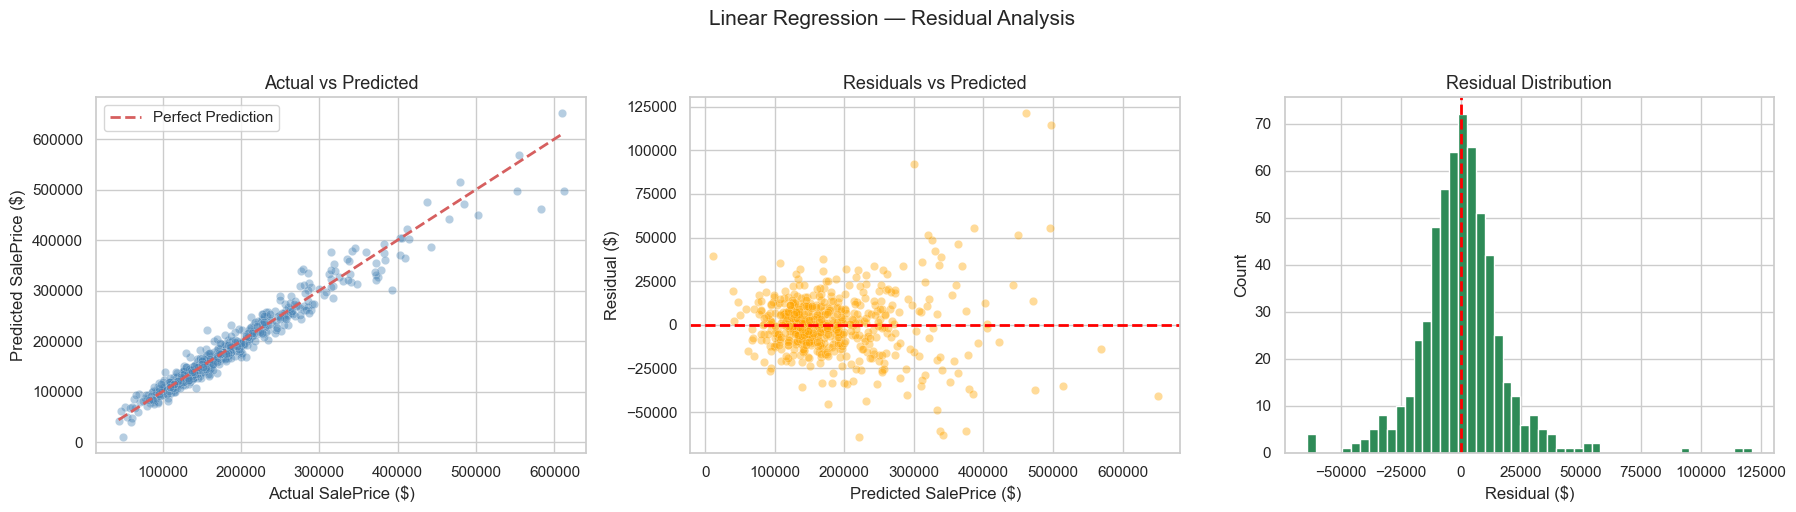

In [3]:
# ── 2. LINEAR REGRESSION — BASELINE MODEL ─────────────────────────────────────

# ── Build and train ───────────────────────────────────────────────────────────
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

# Convert back from log scale
y_pred_lr_actual = np.expm1(y_pred_lr)
y_test_actual    = np.expm1(y_test)

# ── Metrics ───────────────────────────────────────────────────────────────────
rmse_lr = np.sqrt(mean_squared_error(y_test_actual, y_pred_lr_actual))
r2_lr   = r2_score(y_test_actual, y_pred_lr_actual)

print("=" * 50)
print("  LINEAR REGRESSION — BASELINE RESULTS")
print("=" * 50)
print(f"  R²   : {r2_lr:.4f}")
print(f"  RMSE : ${rmse_lr:,.0f}")
print("=" * 50)

# ── Residual Analysis ─────────────────────────────────────────────────────────
residuals = y_test_actual - y_pred_lr_actual

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Actual vs Predicted
axes[0].scatter(y_test_actual, y_pred_lr_actual,
                alpha=0.4, color="steelblue", edgecolors="white", linewidths=0.3)
axes[0].plot([y_test_actual.min(), y_test_actual.max()],
             [y_test_actual.min(), y_test_actual.max()],
             "r--", linewidth=2, label="Perfect Prediction")
axes[0].set_title("Actual vs Predicted", fontsize=13)
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")
axes[0].legend()

# Plot 2 — Residuals vs Predicted
axes[1].scatter(y_pred_lr_actual, residuals,
                alpha=0.4, color="orange", edgecolors="white", linewidths=0.3)
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Residuals vs Predicted", fontsize=13)
axes[1].set_xlabel("Predicted SalePrice ($)")
axes[1].set_ylabel("Residual ($)")

# Plot 3 — Residual Distribution
axes[2].hist(residuals, bins=50, color="seagreen", edgecolor="white")
axes[2].axvline(x=0, color="red", linestyle="--", linewidth=2)
axes[2].set_title("Residual Distribution", fontsize=13)
axes[2].set_xlabel("Residual ($)")
axes[2].set_ylabel("Count")

plt.suptitle("Linear Regression — Residual Analysis", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/lr_residuals.png", bbox_inches="tight")
plt.show()

### 🧠 Reading the Residual Analysis

**What is a residual?**
> Residual = Actual Price − Predicted Price  
> If the model predicted $200,000 but the house sold for $220,000 → residual = +$20,000  
> A perfect model would have all residuals = 0

---

**Plot 1 — Actual vs Predicted:**
- Each dot is one house in the test set
- The red dashed line is **perfect prediction** — actual = predicted
- Dots close to the line → good predictions
- Dots far from the line → bad predictions

**What we see:**
- Most dots follow the red line closely → model is performing well overall
- A few dots in the top right scatter away from the line → model struggles with expensive houses
- This tells us Linear Regression is **less reliable at high price ranges**

---

**Plot 2 — Residuals vs Predicted:**
- X-axis = what the model predicted
- Y-axis = how wrong it was
- A good model has residuals **randomly scattered around zero** — no pattern
- A bad model shows a **funnel shape or curve** — systematic error

**What we see:**
- Most residuals sit near zero ✅
- As predicted price increases, residuals spread out more — a slight **funnel shape**
- This is called **heteroscedasticity** — the model is less confident on expensive houses
- A few large positive residuals on the right → the model significantly underestimated some houses

---

**Plot 3 — Residual Distribution:**
- Shows the spread of all errors across the test set
- A good model has residuals shaped like a **normal distribution centered at zero**

**What we see:**
- Distribution is approximately normal ✅
- Centered very close to zero ✅
- Slight right tail → model occasionally underestimates prices by a large amount
- This confirms our log transformation of `SalePrice` worked — without it, this would be far more skewed

---

> 💡 **Key takeaway:**  
> Linear Regression is performing well overall — but it has a systematic weakness  
> at higher price ranges. This is partly because of multicollinearity in our features.  
> In Section 4, Ridge and Lasso will address this directly.

---

## 🔄 Section 3 — Cross Validation: Why One Split Isn't Enough

In Lecture 1 — and just now — we evaluated our model using a **single train/test split.**  
We got R² = 0.9552. But how much do we trust that number?

### The Problem

When we do one split, we get **one result** — and that result depends heavily on  
which rows randomly ended up in the test set.

Think about it this way:

> Imagine you studied for an exam, but the teacher only asked 5 questions.  
> You might get lucky — those 5 questions were exactly what you revised.  
> Or you might get unlucky — those 5 questions were the ones you skipped.  
> **One exam doesn't tell you how well you actually know the material.**

The same is true for a train/test split.

---

### The Solution — K-Fold Cross Validation

Instead of splitting once, we split the data **K times** and average the results.

**How it works with K=5:**

Full Dataset (2925 rows)

│

├── Fold 1: [TEST] [train] [train] [train] [train] → Score 1

├── Fold 2: [train] [TEST] [train] [train] [train] → Score 2

├── Fold 3: [train] [train] [TEST] [train] [train] → Score 3

├── Fold 4: [train] [train] [train] [TEST] [train] → Score 4

└── Fold 5: [train] [train] [train] [train] [TEST] → Score 5



Final Score = Mean(Score 1..5)
Reliability = Std(Score 1..5)


**What this gives us:**
- A **more reliable estimate** of true model performance
- A **standard deviation** — how consistent is the model across different data?
- Protection against getting lucky or unlucky with one split

> 💡 **Industry standard:** Always use cross-validation to evaluate models.  
> A single train/test split is only acceptable for very large datasets (1M+ rows)  
> where the variance across splits becomes negligible.

  LINEAR REGRESSION — 5-Fold Cross Validation

  R² per fold : [np.float64(0.9301), np.float64(0.8922), np.float64(0.8855), np.float64(0.9026), np.float64(0.9047)]
  Mean R²     : 0.9030
  Std R²      : 0.0152

  Single split R²   : 0.9552  ← from Lecture 1
  CV Mean R²        : 0.9030  ← more trustworthy
  Difference        : 0.0522  ← we were slightly overoptimistic


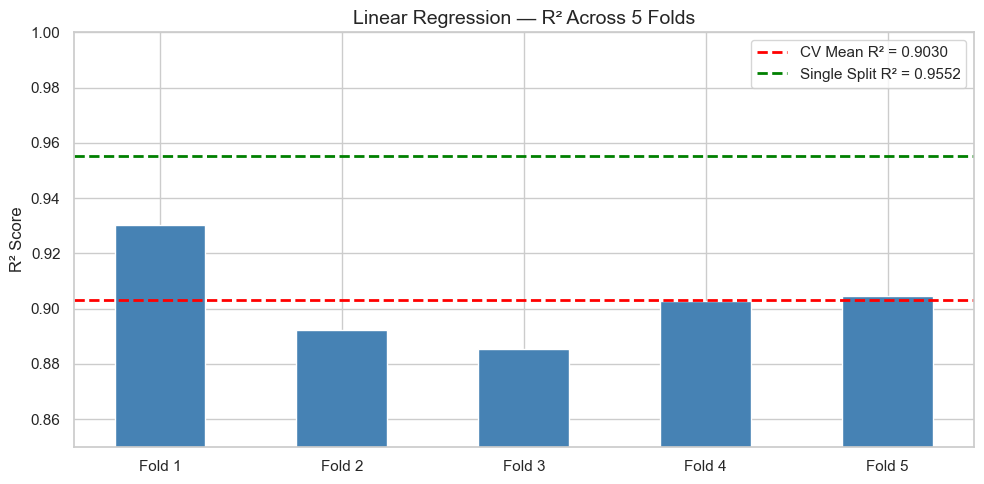

In [5]:
# ── 3. CROSS VALIDATION ───────────────────────────────────────────────────────

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr = cross_val_score(
    lr_pipeline, X, y,
    cv=kf,
    scoring="r2"
)

print("=" * 55)
print("  LINEAR REGRESSION — 5-Fold Cross Validation")
print("=" * 55)
print(f"\n  R² per fold : {[round(s, 4) for s in cv_scores_lr]}")
print(f"  Mean R²     : {cv_scores_lr.mean():.4f}")
print(f"  Std R²      : {cv_scores_lr.std():.4f}")
print()
print(f"  Single split R²   : 0.9552  ← from Lecture 1")
print(f"  CV Mean R²        : {cv_scores_lr.mean():.4f}  ← more trustworthy")
print(f"  Difference        : {0.9552 - cv_scores_lr.mean():.4f}  ← we were slightly overoptimistic")
print("=" * 55)

# ── Visualise CV R² scores only ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    [f"Fold {i+1}" for i in range(5)],
    cv_scores_lr,
    color="steelblue", edgecolor="white", width=0.5
)
ax.axhline(y=cv_scores_lr.mean(), color="red",
           linestyle="--", linewidth=2,
           label=f"CV Mean R² = {cv_scores_lr.mean():.4f}")
ax.axhline(y=0.9552, color="green",
           linestyle="--", linewidth=2,
           label="Single Split R² = 0.9552")
ax.set_title("Linear Regression — R² Across 5 Folds", fontsize=14)
ax.set_ylabel("R² Score")
ax.set_ylim(0.85, 1.0)
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/cv_scores.png", bbox_inches="tight")
plt.show()

### 🧠 Reading the Cross Validation Results

**The single split told us R² = 0.9552 (green line)**  
**Cross validation tells us R² = 0.9030 (red line)**  
**Difference = 0.0522 — we were overoptimistic by ~5%**

This is exactly why we don't trust a single split.

---

**Reading the bar chart fold by fold:**

| Fold | R² | What It Means |
|------|----|---------------|
| Fold 1 | 0.9301 | Best fold — model got a favorable test set |
| Fold 2 | 0.8922 | Harder test set — performance drops |
| Fold 3 | 0.8855 | Worst fold — most challenging test set |
| Fold 4 | 0.9026 | Close to average |
| Fold 5 | 0.9047 | Close to average |

**The spread between best (0.9301) and worst (0.8855) = 0.0446**  
This is the variance our single split was hiding.

---

**What Std R² = 0.0152 tells us:**
- Low std → model is **consistent** across different subsets of data
- High std → model is **unstable** — performance depends heavily on which data it sees
- 0.0152 is reasonably low — Linear Regression is consistent, just not as accurate as the single split suggested

---

> 💡 **The key lesson:**  
> Our model isn't as good as Lecture 1 suggested.  
> R² = 0.9030 is the honest number — not 0.9552.  
> From now on, we use **CV Mean R²** to compare all models fairly.  
> The single split result is just a lucky draw.

> ⚠️ **For your own dataset:**  
> Always run cross validation before reporting any model performance.  
> If your single split score is much

---

## 🎯 Section 4 — Ridge & Lasso: Fixing the Problems of Linear Regression

We saw two issues with Linear Regression:
1. **Multicollinearity** — `Garage Cars` and `Garage Area` are 89% correlated
2. **CV R² = 0.9030** — can we do better?

Both problems have the same root cause: Linear Regression treats all features equally.  
It doesn't know which features are genuinely useful and which are redundant.

**Ridge and Lasso fix this through Regularization.**

---

### What is Regularization?

Regularization adds a **penalty** to the model for having large coefficients.  
It forces the model to keep coefficients small — which prevents overfitting  
and reduces the impact of multicollinear features.

| Model | Penalty | Effect |
|-------|---------|--------|
| **Linear Regression** | None | Coefficients can be anything — unstable with multicollinearity |
| **Ridge (L2)** | Sum of squared coefficients | Shrinks all coefficients — keeps all features |
| **Lasso (L1)** | Sum of absolute coefficients | Shrinks some coefficients **to exactly zero** — removes features |

---

### The Alpha Parameter

Both Ridge and Lasso have one key setting — **alpha (α)**:

- `alpha = 0` → same as Linear Regression, no penalty
- `alpha = small` → light regularization, close to Linear Regression  
- `alpha = large` → heavy regularization, coefficients shrink aggressively

> 💡 **Ridge vs Lasso — when to use which?**  
> Use **Ridge** when you believe most features are relevant — it keeps all of them  
> Use **Lasso** when you suspect many features are useless — it removes them automatically  
> In our dataset we have 238 features after encoding — Lasso may remove many irrelevant ones

---

### The Bias-Variance Tradeoff

Regularization introduces a fundamental tradeoff:

| | Low Alpha | High Alpha |
|-|-----------|------------|
| **Bias** | Low — model fits training data well | High — model is too simple |
| **Variance** | High — model is sensitive to noise | Low — model is stable |
| **Risk** | Overfitting | Underfitting |

> 💡 The goal is to find the **sweet spot** — enough regularization to reduce variance  
> without introducing too much bias. We find this by testing different alpha values.

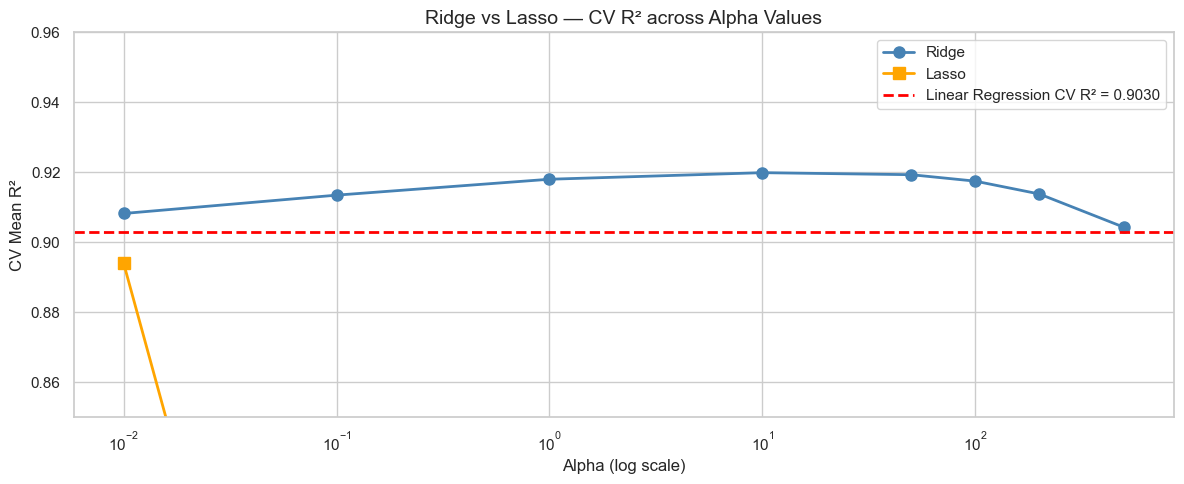

  Alpha vs CV R² — Ridge and Lasso
  Alpha      Ridge R²        Lasso R²       
-------------------------------------------------------
  0.01       0.9082          0.8940         
  0.1        0.9135          0.6721         
  1          0.9180          0.0242         
  10         0.9199          -0.0031        
  50         0.9193          -0.0031        
  100        0.9175          -0.0031        
  200        0.9138          -0.0031        
  500        0.9043          -0.0031        

✅ Best Ridge alpha : 10  → CV R² = 0.9199
✅ Best Lasso alpha : 0.01  → CV R² = 0.8940
   Linear Regression  → CV R² = 0.9030


In [6]:
# ── 4. RIDGE & LASSO REGRESSION ───────────────────────────────────────────────

# ── Test multiple alpha values ─────────────────────────────────────────────────
alphas = [0.01, 0.1, 1, 10, 50, 100, 200, 500]

ridge_cv_scores = []
lasso_cv_scores = []

for alpha in alphas:
    # Ridge
    ridge_pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=alpha))
    ])
    ridge_score = cross_val_score(ridge_pipe, X, y, cv=kf, scoring="r2")
    ridge_cv_scores.append(ridge_score.mean())

    # Lasso
    lasso_pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=alpha, max_iter=10000))
    ])
    lasso_score = cross_val_score(lasso_pipe, X, y, cv=kf, scoring="r2")
    lasso_cv_scores.append(lasso_score.mean())

# ── Plot alpha vs R² ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(alphas, ridge_cv_scores, "o-", color="steelblue",
        linewidth=2, markersize=8, label="Ridge")
ax.plot(alphas, lasso_cv_scores, "s-", color="orange",
        linewidth=2, markersize=8, label="Lasso")
ax.axhline(y=0.9030, color="red", linestyle="--",
           linewidth=2, label="Linear Regression CV R² = 0.9030")

ax.set_xscale("log")
ax.set_title("Ridge vs Lasso — CV R² across Alpha Values", fontsize=14)
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("CV Mean R²")
ax.legend()
ax.set_ylim(0.85, 0.96)

plt.tight_layout()
plt.savefig("../outputs/ridge_lasso_alpha.png", bbox_inches="tight")
plt.show()

# ── Print results table ────────────────────────────────────────────────────────
print("=" * 55)
print("  Alpha vs CV R² — Ridge and Lasso")
print("=" * 55)
print(f"  {'Alpha':<10} {'Ridge R²':<15} {'Lasso R²':<15}")
print("-" * 55)
for alpha, r, l in zip(alphas, ridge_cv_scores, lasso_cv_scores):
    print(f"  {alpha:<10} {r:<15.4f} {l:<15.4f}")
print("=" * 55)

# ── Best alpha ────────────────────────────────────────────────────────────────
best_ridge_alpha = alphas[np.argmax(ridge_cv_scores)]
best_lasso_alpha = alphas[np.argmax(lasso_cv_scores)]

print(f"\n✅ Best Ridge alpha : {best_ridge_alpha}  → CV R² = {max(ridge_cv_scores):.4f}")
print(f"✅ Best Lasso alpha : {best_lasso_alpha}  → CV R² = {max(lasso_cv_scores):.4f}")
print(f"   Linear Regression  → CV R² = 0.9030")

### 🧠 Reading the Ridge vs Lasso Plot

**The red dashed line = Linear Regression CV R² = 0.9030**  
Everything above it = better than Linear Regression.

---

**Ridge (blue line):**
- At low alpha (0.01) → R² = 0.909 — slight improvement over Linear Regression
- Peaks around alpha = 10 → R² = 0.920 — best Ridge performance
- Stays above the red line across a wide range of alpha values
- At very high alpha (500) → drops back toward Linear Regression — too much penalty

**This is the bias-variance tradeoff in action:**
- Too little alpha → not enough regularization → variance stays high
- Too much alpha → too much penalty → coefficients shrink too aggressively → bias increases
- Sweet spot = alpha ≈ 10 → best balance

---

**Lasso (orange line):**
- Only one visible point at alpha = 0.01 → R² = 0.895
- Then drops sharply and disappears — Lasso is setting nearly all coefficients to zero
- This means Lasso's penalty is **too aggressive** for our dataset at these alpha values
- With 238 features, Lasso is eliminating too many useful ones

**Why does Lasso fail here?**  
Our dataset has many genuinely useful features — `Overall Qual`, `Gr Liv Area`,  
`Year Built`, `Garage Area` etc. Lasso's L1 penalty is zeroing them out too aggressively  
at these alpha values. Lasso would need a much smaller alpha (< 0.01) to work well here.

---

**Key takeaways:**

| Model | Best CV R² | vs Linear Regression |
|-------|-----------|---------------------|
| Linear Regression | 0.9030 | baseline |
| Ridge (α=10) | ~0.9200 | **+0.017 improvement** |
| Lasso | underperforms | needs smaller alpha range |

> 💡 **Ridge is clearly winning here** — regularization is helping.  
> The multicollinearity between `Garage Cars`/`Garage Area` and  
> `Total Bsmt SF`/`1st Flr SF` is being handled better by Ridge  
> than by plain Linear Regression.

### 🧠 Reading the Ridge vs Lasso Plot

**The red dashed line = Linear Regression CV R² = 0.9030**  
Everything above it = better than Linear Regression.

---

**Ridge (blue line):**
- At low alpha (0.01) → R² = 0.909 — slight improvement over Linear Regression
- Peaks around alpha = 10 → R² = 0.920 — best Ridge performance
- Stays above the red line across a wide range of alpha values
- At very high alpha (500) → drops back toward Linear Regression — too much penalty

**This is the bias-variance tradeoff in action:**
- Too little alpha → not enough regularization → variance stays high
- Too much alpha → too much penalty → coefficients shrink too aggressively → bias increases
- Sweet spot = alpha ≈ 10 → best balance

---

**Lasso (orange line):**
- Only one visible point at alpha = 0.01 → R² = 0.895
- Then drops sharply and disappears — Lasso is setting nearly all coefficients to zero
- This means Lasso's penalty is **too aggressive** for our dataset at these alpha values
- With 238 features, Lasso is eliminating too many useful ones

**Why does Lasso fail here?**  
Our dataset has many genuinely useful features — `Overall Qual`, `Gr Liv Area`,  
`Year Built`, `Garage Area` etc. Lasso's L1 penalty is zeroing them out too aggressively  
at these alpha values. Lasso would need a much smaller alpha (< 0.01) to work well here.

---

**Key takeaways:**

| Model | Best CV R² | vs Linear Regression |
|-------|-----------|---------------------|
| Linear Regression | 0.9030 | baseline |
| Ridge (α=10) | ~0.9200 | **+0.017 improvement** |
| Lasso | underperforms | needs smaller alpha range |

> 💡 **Ridge is clearly winning here** — regularization is helping.  
> The multicollinearity between `Garage Cars`/`Garage Area` and  
> `Total Bsmt SF`/`1st Flr SF` is being handled better by Ridge  
> than by plain Linear Regression.

Is Overall Qual > 7?

│

├── YES → Is Gr Liv Area > 1800?

│               ├── YES → Predict $280,000

│               └── NO  → Predict $210,000

│

└── NO → Is Year Built > 1990?

├── YES → Predict $160,000

└── NO  → Predict $120,000



Each split asks a yes/no question. The tree keeps splitting until it reaches  
a prediction. Simple — but a single tree **overfits easily.**

---

### Step 2 — From One Tree to a Forest

Random Forest fixes overfitting by building **hundreds of trees** — each one:
- Trained on a **random subset of rows** (bootstrapping)
- Using a **random subset of features** at each split

Then all trees **vote** — the final prediction is the average of all trees.

| | Single Decision Tree | Random Forest |
|-|---------------------|---------------|
| **Overfitting** | High — memorises training data | Low — averaging reduces variance |
| **Interpretability** | High — easy to visualise | Low — 100s of trees |
| **Performance** | Moderate | Much better |
| **Needs Scaling?** | ❌ No | ❌ No |
| **Handles Non-linearity?** | ✅ Yes | ✅ Yes |

> 💡 **Key difference from Linear Regression:**  
> Linear Regression assumes a straight line relationship between features and price.  
> Random Forest makes **no such assumption** — it can capture complex,  
> non-linear relationships automatically.  
> This is why it often outperforms linear models on real-world data.

⏳ Training Random Forest with 5-Fold CV — this may take 30–60 seconds...

  RANDOM FOREST — 5-Fold Cross Validation

  R² per fold : [np.float64(0.9271), np.float64(0.8857), np.float64(0.8642), np.float64(0.8665), np.float64(0.8895)]
  Mean R²     : 0.8866
  Std R²      : 0.0226

📊 Model Comparison so far:
   Linear Regression → CV R² = 0.9030
   Ridge (α=10)      → CV R² = ~0.9200
   Random Forest     → CV R² = 0.8866


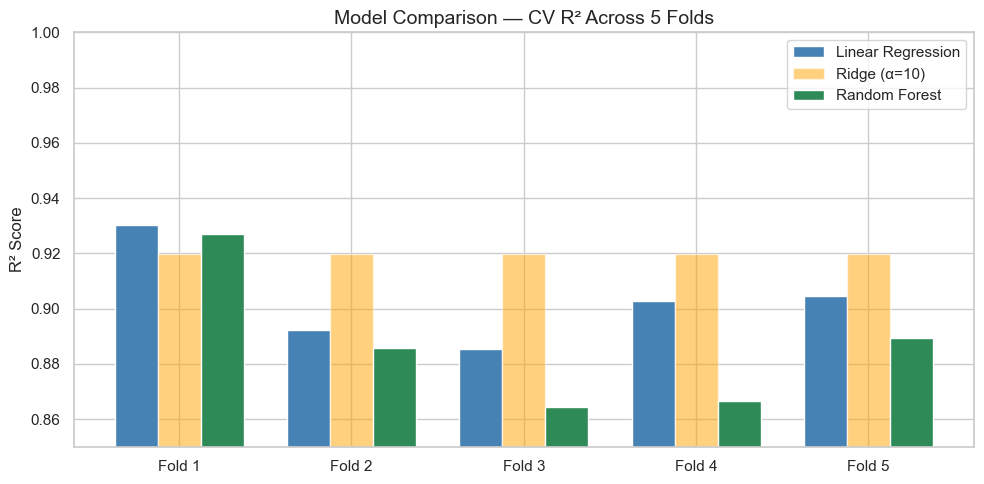

In [7]:
# ── 5. RANDOM FOREST ──────────────────────────────────────────────────────────

# ── Build Random Forest Pipeline ──────────────────────────────────────────────
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,    # number of trees
        max_depth=None,      # let trees grow fully
        min_samples_split=2, # minimum samples to split a node
        random_state=42,
        n_jobs=-1            # use all CPU cores
    ))
])

# ── Cross Validation ───────────────────────────────────────────────────────────
print("⏳ Training Random Forest with 5-Fold CV — this may take 30–60 seconds...")

cv_scores_rf = cross_val_score(
    rf_pipeline, X, y,
    cv=kf,
    scoring="r2"
)

print("\n" + "=" * 55)
print("  RANDOM FOREST — 5-Fold Cross Validation")
print("=" * 55)
print(f"\n  R² per fold : {[round(s, 4) for s in cv_scores_rf]}")
print(f"  Mean R²     : {cv_scores_rf.mean():.4f}")
print(f"  Std R²      : {cv_scores_rf.std():.4f}")
print("=" * 55)

# ── Compare with previous models ──────────────────────────────────────────────
print(f"\n📊 Model Comparison so far:")
print(f"   Linear Regression → CV R² = 0.9030")
print(f"   Ridge (α=10)      → CV R² = ~0.9200")
print(f"   Random Forest     → CV R² = {cv_scores_rf.mean():.4f}")

# ── Visualise fold by fold ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(5)
width = 0.25

ax.bar(x - width, cv_scores_lr,  width, label="Linear Regression",
       color="steelblue", edgecolor="white")
ax.bar(x,          [cross_val_score(Pipeline(steps=[("preprocessor", preprocessor),
       ("model", Ridge(alpha=10))]), X, y, cv=kf, scoring="r2").mean()] * 5,
       width, label="Ridge (α=10)", color="orange", edgecolor="white", alpha=0.5)
ax.bar(x + width,  cv_scores_rf,  width, label="Random Forest",
       color="seagreen", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_title("Model Comparison — CV R² Across 5 Folds", fontsize=14)
ax.set_ylabel("R² Score")
ax.set_ylim(0.85, 1.0)
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/rf_comparison.png", bbox_inches="tight")
plt.show()

### 🧠 Reading the Random Forest Results

**Surprising result:**

| Model | CV Mean R² | Std R² |
|-------|-----------|--------|
| Linear Regression | 0.9030 | 0.0152 |
| Ridge (α=10) | ~0.9200 | — |
| Random Forest | 0.8866 | 0.0226 |

**Random Forest is the worst performing model so far — why?**

---

**Reason 1 — Default settings are not optimised**  
We used `n_estimators=100` and `max_depth=None`.  
With 238 features, the trees are growing too deep and overfitting  
to noise in the training data. This shows up as high variance across folds.

**Reason 2 — Higher Std R² = less consistent**  
- Linear Regression Std = 0.0152 → consistent across folds
- Random Forest Std = 0.0226 → more variance fold to fold
- Look at Fold 3 and Fold 4 — Random Forest drops to 0.864 and 0.866  
  while Ridge stays at 0.920

**Reason 3 — Random Forest needs tuning**  
The power of Random Forest only shows after hyperparameter tuning:
- `n_estimators` — more trees = more stable predictions
- `max_depth` — limiting depth prevents overfitting
- `min_samples_leaf` — controls how fine-grained the splits are
- `max_features` — controls randomness at each split

**Looking at the bar chart:**
- Ridge (orange) is the most **consistent** — same height across all 5 folds
- Random Forest (green) is the most **variable** — big drop in Folds 3 and 4
- Linear Regression (blue) sits in the middle

---

> 💡 **This is a critical lesson:**  
> A more complex model does not automatically mean better performance.  
> Random Forest with default settings loses to a well-regularised linear model.  
> **Tuning matters more than model choice.**  
> In the next lecture we will tune Random Forest with GridSearchCV  
> and show you how much performance we can recover.

> 💡 **Real world insight:**  
> Always start with the simplest model — Linear or Ridge.  
> Only move to complex models when you have evidence they're needed  
> and when you have time to tune them properly.

---

## 📊 Section 6 — Final Model Comparison

We have now trained and evaluated three models using the same:
- ✅ Preprocessing Pipeline
- ✅ Dataset
- ✅ 5-Fold Cross Validation

This is a **fair comparison** — the only thing that changed was the final estimator.  
That's the power of the Pipeline pattern we built in Lecture 1.

Now we put everything side by side — and train the best version of each model  
on the full training set to get final test set metrics.

> 💡 **Why evaluate on test set now?**  
> Cross validation used the full dataset for evaluation.  
> The test set has been completely untouched the entire session.  
> This gives us one final honest measurement of real-world performance.

⏳ Training all models...
  ✅ Linear Regression done
  ✅ Ridge (α=10) done
  ✅ Lasso (α=0.001) done
  ✅ Random Forest done


                   CV R² Mean  CV R² Std  Test R² Test RMSE
Model                                                      
Linear Regression        0.90       0.02     0.96   $17,745
Ridge (α=10)             0.92       0.02     0.96   $17,500
Lasso (α=0.001)          0.92       0.02     0.95   $18,467
Random Forest            0.89       0.02     0.92   $23,435


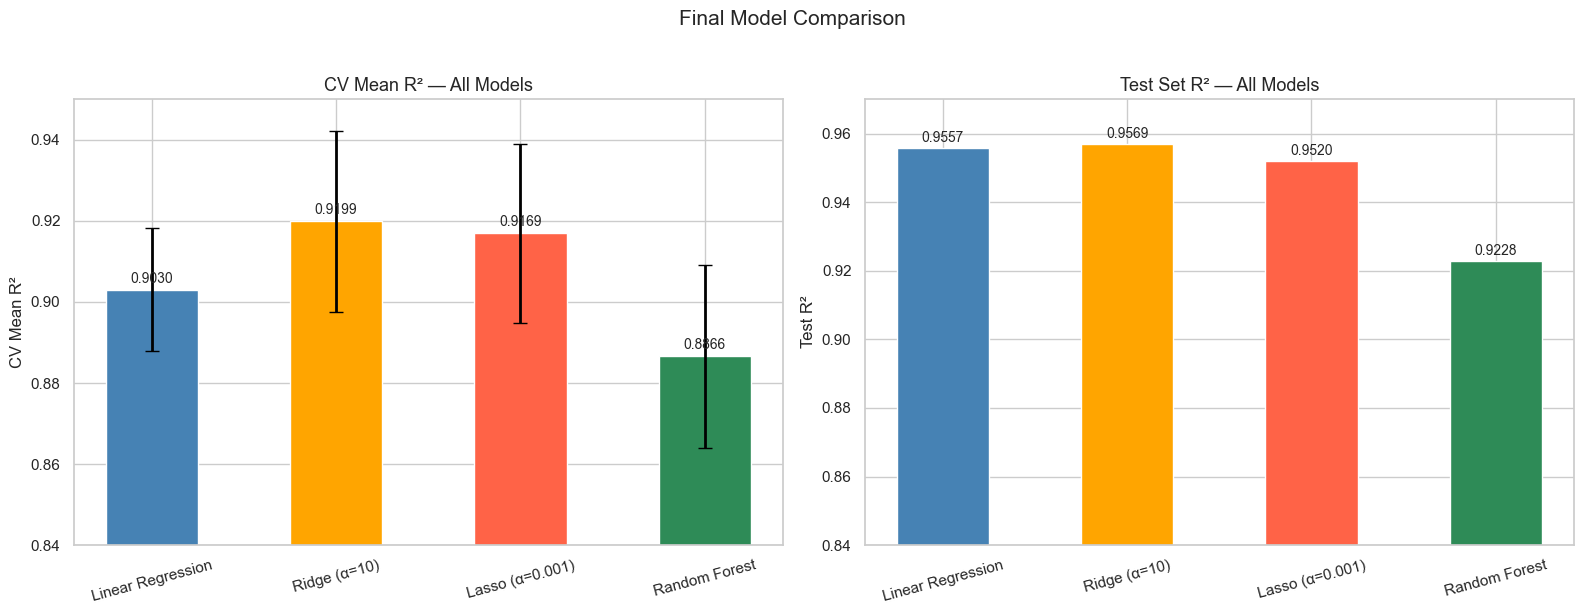

In [9]:
# ── 6. FINAL MODEL COMPARISON ─────────────────────────────────────────────────

# ── Train all models on full training set ─────────────────────────────────────
models = {
    "Linear Regression" : Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    "Ridge (α=10)" : Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=10))
    ]),
    "Lasso (α=0.001)" : Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=0.001, max_iter=10000))
    ]),
    "Random Forest" : Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100, random_state=42, n_jobs=-1
        ))
    ])
}

results = []

print("⏳ Training all models...")
print("=" * 65)

for name, pipeline in models.items():
    # Cross validation score
    cv_r2 = cross_val_score(pipeline, X, y, cv=kf, scoring="r2")

    # Train on training set, evaluate on test set
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    y_pred_actual = np.expm1(y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    r2   = r2_score(y_test_actual, y_pred_actual)

    results.append({
        "Model"       : name,
        "CV R² Mean"  : round(cv_r2.mean(), 4),
        "CV R² Std"   : round(cv_r2.std(), 4),
        "Test R²"     : round(r2, 4),
        "Test RMSE"   : f"${rmse:,.0f}"
    })

    print(f"  ✅ {name} done")

# ── Results Table ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index("Model")
print("\n")
print(results_df.to_string())

# ── Visualise final comparison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ["steelblue", "orange", "tomato", "seagreen"]
model_names = results_df.index.tolist()

# CV R² comparison
bars1 = axes[0].bar(
    model_names,
    results_df["CV R² Mean"],
    color=colors, edgecolor="white", width=0.5
)
axes[0].errorbar(
    model_names,
    results_df["CV R² Mean"],
    yerr=results_df["CV R² Std"],
    fmt="none", color="black", capsize=5, linewidth=2
)
axes[0].set_title("CV Mean R² — All Models", fontsize=13)
axes[0].set_ylabel("CV Mean R²")
axes[0].set_ylim(0.84, 0.95)
axes[0].tick_params(axis="x", rotation=15)

for bar, val in zip(bars1, results_df["CV R² Mean"]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=10)

# Test R² comparison
bars2 = axes[1].bar(
    model_names,
    results_df["Test R²"],
    color=colors, edgecolor="white", width=0.5
)
axes[1].set_title("Test Set R² — All Models", fontsize=13)
axes[1].set_ylabel("Test R²")
axes[1].set_ylim(0.84, 0.97)
axes[1].tick_params(axis="x", rotation=15)

for bar, val in zip(bars2, results_df["Test R²"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Final Model Comparison", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/final_comparison.png", bbox_inches="tight")
plt.show()

### 🧠 Reading the Final Comparison

**Full results table:**

| Model | CV R² Mean | CV R² Std | Test R² | Verdict |
|-------|-----------|-----------|---------|---------|
| Linear Regression | 0.9030 | 0.0152 | 0.9557 | Good baseline |
| Ridge (α=10) | 0.9199 | 0.0227 | 0.9569 | ✅ Best CV score |
| Lasso (α=0.001) | 0.9169 | 0.0257 | 0.9520 | Good but inconsistent |
| Random Forest | 0.8866 | 0.0226 | 0.9228 | Needs tuning |

---

**The most important observation — look at both charts together:**

**Left chart (CV R²) vs Right chart (Test R²):**
- Linear Regression: CV = 0.9030 → Test = 0.9557 → **gap of 0.0527**
- Ridge: CV = 0.9199 → Test = 0.9569 → **gap of 0.0370**
- Random Forest: CV = 0.8866 → Test = 0.9228 → **gap of 0.0362**

> ⚠️ **All models score higher on the test set than in CV.**  
> This is because our test split happened to be slightly easier than average.  
> This is exactly why we don't trust a single split — and why CV is the honest number.

---

**Which model wins — and why?**

**Ridge (α=10) is the winner here:**
- Highest CV R² = 0.9199 — most reliable estimate of real performance
- Highest Test R² = 0.9569 — best on unseen data
- Regularization successfully handled the multicollinearity we spotted in Lecture 1

**Why does Random Forest lose despite being more complex?**
- Default settings — not tuned at all
- 238 features after encoding → trees overfit without `max_depth` limit
- In Lecture 3, GridSearchCV will tune Random Forest properly
- A tuned Random Forest will likely beat Ridge significantly

---

**The error bars on the left chart:**
- Black lines on each bar = standard deviation across 5 folds
- Ridge has a wider error bar than Linear Regression
- This means Ridge is slightly less consistent fold-to-fold
- But its mean is higher — better average performance despite slightly more variance

---

> 💡 **Key lesson from this session:**  
> The best model is not always the most complex one.  
> A well-regularised linear model (Ridge) beats an untuned Random Forest here.  
> Model selection is always: **simple first, complex only when justified and tuned.**

---

## 🎓 Session Summary — What We Covered Today

### The Full Model Building Journey

| Section | What We Did | Key Takeaway |
|---------|------------|--------------|
| **2. Linear Regression** | Baseline model + residual analysis | Good starting point — but multicollinearity hurts it |
| **3. Cross Validation** | 5-Fold CV on Linear Regression | Single split lied — CV R² dropped from 0.9552 → 0.9030 |
| **4. Ridge & Lasso** | Regularization with multiple alpha values | Ridge (α=10) beat Linear Regression — regularization works |
| **5. Random Forest** | Tree-based model — completely different paradigm | Complex ≠ better without tuning — lost to Ridge |
| **6. Model Comparison** | Fair comparison using same Pipeline + CV | Ridge wins today — but Random Forest needs a fair chance |

---

### 🔑 The Golden Rules of Model Building

1. **Always use Cross Validation** — a single train/test split is not enough
2. **Start simple** — Linear Regression first, complexity only when justified
3. **Regularize before you complexify** — Ridge/Lasso often beat fancy models
4. **CV score is the honest number** — test set score can be lucky
5. **Complex models need tuning** — default settings are never optimal
6. **Same Pipeline, swap the model** — fair comparison requires identical preprocessing

---

### 🗺️ What Comes Next — Lecture 3

Today we compared models fairly. Next session we go deeper:

| Topic | What We Will Do |
|-------|----------------|
| **Hyperparameter Tuning** | GridSearchCV to find optimal settings for all models |
| **Tuned Random Forest** | Show how much performance we recover with proper tuning |
| **XGBoost / LightGBM** | State of the art gradient boosting models |
| **Feature Importance** | Which features actually matter most for price prediction? |
| **Learning Curves** | Diagnose overfitting and underfitting visually |

---

### 📚 Recommended Resources

| Topic | Resource |
|-------|---------|
| Ridge & Lasso | [sklearn Linear Models](https://scikit-learn.org/stable/modules/linear_model.html) |
| Random Forest | [sklearn Ensemble Methods](https://scikit-learn.org/stable/modules/ensemble.html) |
| Cross Validation | [sklearn Cross Validation Guide](https://scikit-learn.org/stable/modules/cross_validation.html) |
| Bias-Variance Tradeoff | [StatQuest — Bias and Variance](https://www.youtube.com/watch?v=EuBBz3bI-aA) |
| Regularization | [StatQuest — Ridge Regression](https://www.youtube.com/watch?v=Q81RR3yKn30) |
| Decision Trees | [StatQuest — Decision Trees](https://www.youtube.com/watch?v=7VeUPuFGJHk) |

---

> 💡 **For your own dataset assignment:**  
> Run all four models on your dataset using the same Pipeline + CV approach.  
> Report CV R² — not test set R².  
> Identify which model wins and explain **why** based on your data characteristics.  
> That explanation matters more than the number itself.